<a href="https://colab.research.google.com/github/KaustubhSN12/deep_learning_exercise/blob/main/DL_P5_Implement_RNN_for_Time_Series_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [ ]:
#create synthetic time series data based on a sine wave
def create_time_series_data():
  time = np.arange(0, 100, 0.1)
  #crete a sine with some noise
  series = np.sin(time) + np.random.normal(0, 0.1, len(time))
  series = series + time /50
  return time, series

In [ ]:
#crete windows of time series data
def create_dataset(data,time_steps=10):
  X,y = [],[]
  for i in range (len(data) - time_steps):
    X.append(data[ i: (i+time_steps)])
    y.append(data[ i + time_steps])
  return np.array(X), np.array(y)

In [ ]:
#enerate the time series data
time , series = create_time_series_data()

#scale the data
scaler = MinMaxScaler(feature_range=(-1,1))
series = scaler.fit_transform(series.reshape(-1,1))

#crete dataset with time windows
time_steps = 20
X , y = create_dataset(series , time_steps)

#reshape X to e [samples , time stpes , features]
X= X.reshape(X.shape[0] , X.shape[1] , 1)

#split the  data train and test
train_size = int(len(X) * 0.8)
X_train , X_test = X[:train_size] , X[train_size:]
y_train , y_test = y[:train_size] , y[train_size:]

#buid a simple RNN model
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(50, activation='relu', input_shape=(time_steps, 1)),
    tf.keras.layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
#compilethe model
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#train the model
history = model.fit(X_train, y_train,
                    epochs=20,
                    batch_size=32,
                    validation_split=0.2,
                    verbose = 1
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.5564 - val_loss: 0.3205
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0887 - val_loss: 0.0451
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0241 - val_loss: 0.0266
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0200 - val_loss: 0.0173
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0173 - val_loss: 0.0231
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0195 - val_loss: 0.0228
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0203 - val_loss: 0.0190
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0173 - val_loss: 0.0199
Epoch 9/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0164 - val_loss: 0.0204
Epoch 10/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0173 - val_loss: 0.0178
Epoch 11/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0166 - val_loss: 0.0162
Epoch 12/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0177 - val_

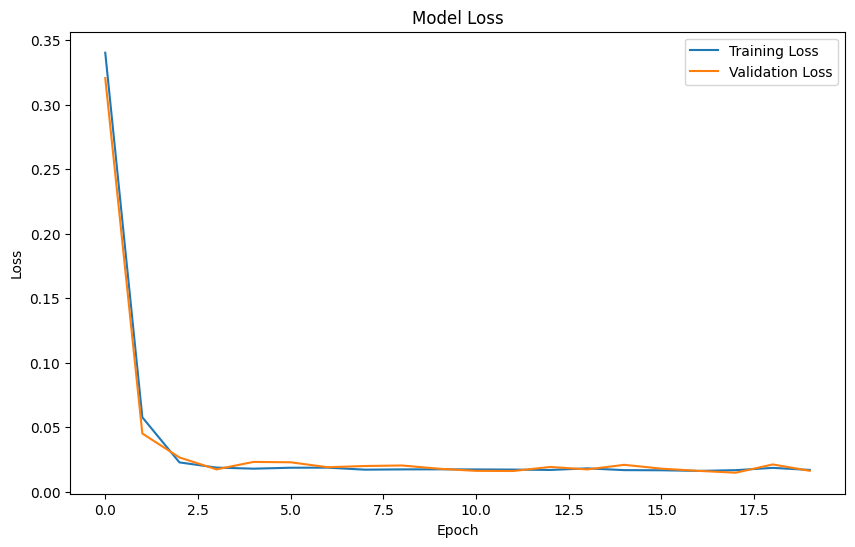

In [ ]:
# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [ ]:
# make prediction
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

#invert the predictions to original scale
train_predict = scaler.inverse_transform(train_predict)
y_train_inv = scaler.inverse_transform(y_train)
test_predict = scaler.inverse_transform(test_predict)
y_test_inv = scaler.inverse_transform(y_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


Train RMSE: 0.2504
Test RMSE: 0.3568


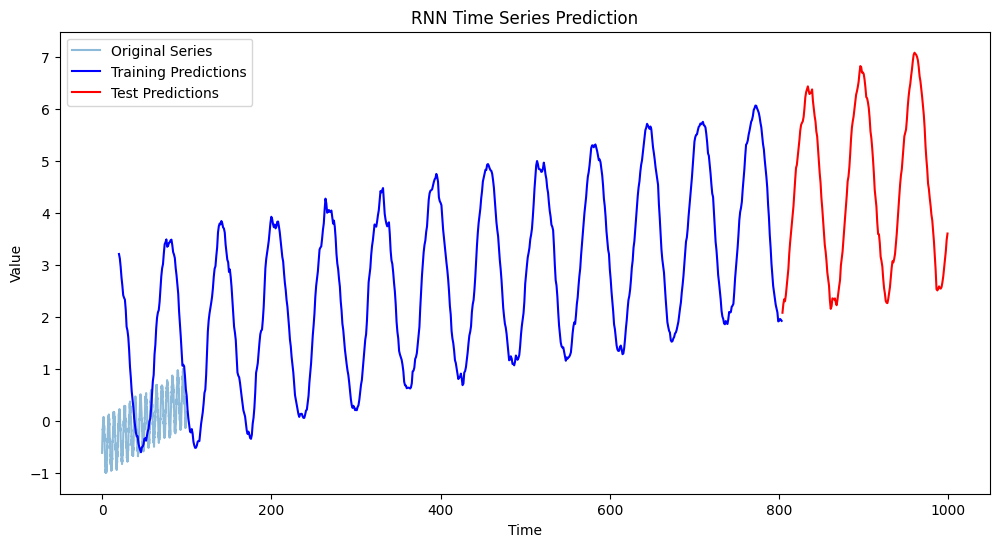

In [ ]:
#calculate RMSE
train_rmse = np.sqrt(np.mean((train_predict - y_train_inv)**2))
test_rmse = np.sqrt(np.mean((test_predict - y_test_inv)**2))
print(f'Train RMSE: {train_rmse:.4f}')
print(f'Test RMSE: {test_rmse:.4f}')

# plot the results
plt.figure(figsize=(12,6))

#plot original series
plt.plot(time, series, label='Original Series',alpha = 0.5)

#plot training predictions
train_plot_idx = np.arange(time_steps, len(train_predict) + time_steps)
plt.plot(train_plot_idx, train_predict,'b',label='Training Predictions')

#plot test predictions
test_plot_idx = np.arange(time_steps + len(train_predict),time_steps + len(train_predict) + len(test_predict))
plt.plot(test_plot_idx, test_predict, 'r', label='Test Predictions')

plt.title('RNN Time Series Prediction')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()


In [ ]:
# Prediction for multiple steps ahead
def predict_sequence(model, first_batch, n_steps):
    curr_batch = first_batch.copy()
    predicted = []

    for _ in range(n_steps):
        # Get prediction for current batch
        curr_pred = model.predict(curr_batch)[0][0]
        predicted.append(curr_pred)

        # Update batch for next prediction
        curr_batch = np.roll(curr_batch, -1, axis=1)
        curr_batch[0, -1, 0] = curr_pred

    return np.array(predicted)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━

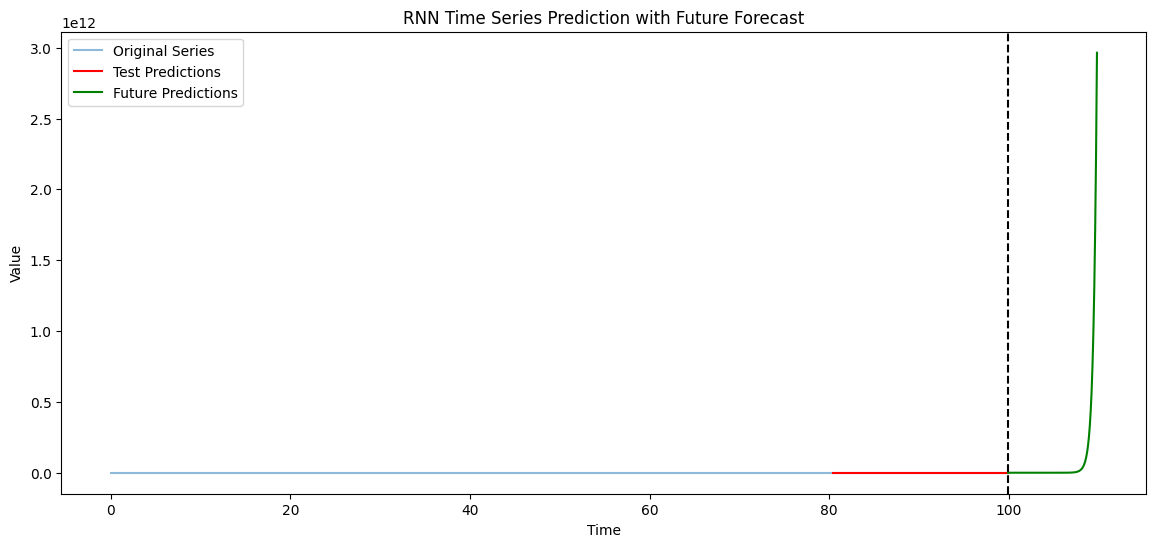

In [ ]:
# Predict 100 steps ahead
future_steps = 100
last_batch = X_test[-1].reshape(1, time_steps, 1)
future_predictions = predict_sequence(model, last_batch, future_steps)
future_predictions = scaler.inverse_transform(future_predictions.reshape(-1, 1))

# Create future time points
future_time = np.arange(time[-1], time[-1] + future_steps*0.1, 0.1)

# Plot with future predictions
plt.figure(figsize=(14, 6))
plt.plot(time, series, label='Original Series', alpha=0.5)
plt.plot(time[test_plot_idx], test_predict, 'r', label='Test Predictions')
plt.plot(future_time, future_predictions, 'g', label='Future Predictions')
plt.axvline(x=time[-1], color='k', linestyle='--')
plt.title('RNN Time Series Prediction with Future Forecast')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()